In [1]:
# The First step is to import important libraries
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt


In [2]:
hr_data=pd.read_csv(r"C:\Users\mohammed hamza\Downloads\HR_file.csv")
hr_data

,Satisfaction Level,Last Evaluation,Number of Projects,Monthly Hours,Total Time at the Company,Work Accidents,Quit the Company,Promoted in Last 5 yrs,Departments,salary,Management
0,0.38,0.53,2,157,3,0,1,0,sales,low,31
1,0.80,0.86,5,262,6,0,1,0,sales,medium,71
2,0.11,0.88,7,272,4,0,1,0,sales,medium,8
3,0.72,0.87,5,223,5,0,1,0,sales,low,68
4,0.37,0.52,2,159,3,0,1,0,sales,low,48
...,...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low,49
14995,0.37,0.48,2,160,3,0,1,0,support,low,3
14996,0.37,0.53,2,143,3,0,1,0,support,low,5
14997,0.11,0.96,6,280,4,0,1,0,support,low,78


In [3]:
hr_data.shape

(14999, 11)

In [4]:
hr_data.describe(include="all")

,Satisfaction Level,Last Evaluation,Number of Projects,Monthly Hours,Total Time at the Company,Work Accidents,Quit the Company,Promoted in Last 5 yrs,Departments,salary,Management
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999,14999,14999.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,3,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sales,low,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4140,7316,NaN
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268,NaN,NaN,11.706780
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281,NaN,NaN,25.300786
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000


In [5]:
print("No of duplicates records - ",hr_data.duplicated().sum())
print("% of duplicate records - ",hr_data.duplicated().sum()/len(hr_data)*100)

No of duplicates records -  1463
% of duplicate records -  9.753983598906593


In [6]:
hr_data.drop_duplicates(inplace=True, keep='first')
hr_data.shape

(13536, 11)

In [7]:
hr_data.drop(['Management','Work Accidents'],axis=1, inplace=True)

In [8]:
# Checking unique values for all the columns using for loop() instead of doing one by one.
for i in hr_data.columns:
    print({i:hr_data[i].unique()})

{'Satisfaction Level': array([0.38, 0.8 , 0.11, 0.72, 0.37, 0.41, 0.1 , 0.92, 0.89, 0.42, 0.45,
       0.84, 0.36, 0.78, 0.76, 0.09, 0.46, 0.4 , 0.82, 0.87, 0.57, 0.43,
       0.13, 0.44, 0.39, 0.85, 0.81, 0.9 , 0.74, 0.79, 0.17, 0.24, 0.91,
       0.71, 0.86, 0.14, 0.75, 0.7 , 0.31, 0.73, 0.83, 0.32, 0.54, 0.27,
       0.77, 0.88, 0.48, 0.19, 0.6 , 0.12, 0.61, 0.33, 0.56, 0.47, 0.28,
       0.55, 0.53, 0.59, 0.66, 0.25, 0.34, 0.58, 0.51, 0.35, 0.64, 0.5 ,
       0.23, 0.15, 0.49, 0.3 , 0.63, 0.21, 0.62, 0.29, 0.2 , 0.16, 0.65,
       0.68, 0.67, 0.22, 0.26, 0.99, 0.98, 1.  , 0.52, 0.93, 0.97, 0.69,
       0.94, 0.96, 0.18, 0.95])}
{'Last Evaluation': array([0.53, 0.86, 0.88, 0.87, 0.52, 0.5 , 0.77, 0.85, 1.  , 0.54, 0.81,
       0.92, 0.55, 0.56, 0.47, 0.99, 0.51, 0.89, 0.83, 0.95, 0.57, 0.49,
       0.46, 0.62, 0.94, 0.48, 0.8 , 0.74, 0.7 , 0.78, 0.91, 0.93, 0.98,
       0.97, 0.79, 0.59, 0.84, 0.45, 0.96, 0.68, 0.82, 0.9 , 0.71, 0.6 ,
       0.65, 0.58, 0.72, 0.67, 0.75, 0.73, 0.63,

In [9]:
hr_data["Total Time at the Company"].value_counts()

Total Time at the Company
3     5885
2     2931
4     2392
5     1405
6      641
10     107
7       94
8       81
Name: count, dtype: int64

In [10]:
hr_data.columns

Index(['Satisfaction Level', 'Last Evaluation', 'Number of Projects',
       'Monthly Hours', 'Total Time at the Company', 'Quit the Company',
       'Promoted in Last 5 yrs', 'Departments ', 'salary'],
      dtype='object')

In [11]:
hr_data.groupby(["Departments ","Quit the Company"])["Departments "].count()/len(hr_data)*100

Departments   Quit the Company
IT            0                    6.043144
              1                    1.987293
RandD         0                    4.499113
              1                    0.893913
accounting    0                    3.782506
              1                    1.499704
hr            0                    3.605201
              1                    1.580969
management    0                    2.836879
              1                    0.664894
marketing     0                    4.144504
              1                    1.470154
product_mng   0                    4.255319
              1                    1.455378
sales         0                   19.865544
              1                    7.402482
support       0                   11.148050
              1                    4.048463
technical     0                   13.696809
              1                    5.119681
Name: Departments , dtype: float64

<Axes: ylabel='count'>

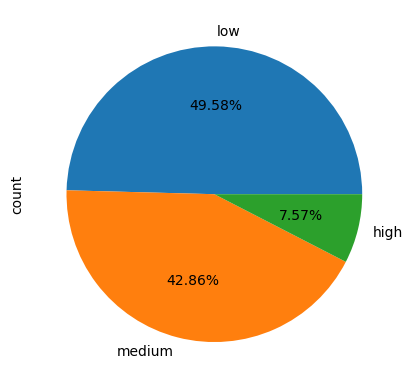

In [12]:
hr_data["salary"].value_counts().plot(kind="pie",autopct="%.2f%%")

<Axes: ylabel='Density'>

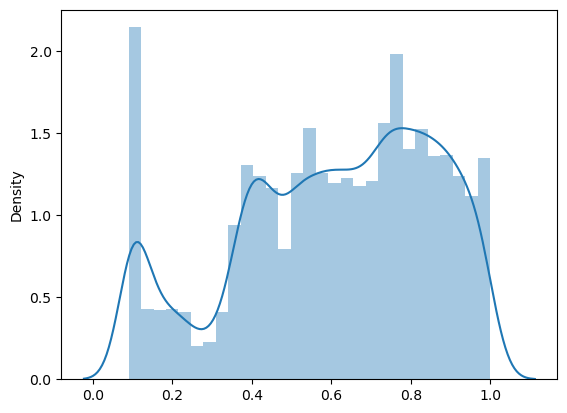

In [13]:
sns.distplot(x=hr_data['Satisfaction Level'])

In [14]:
pd.crosstab(index=hr_data['Promoted in Last 5 yrs'],columns=hr_data['Quit the Company'])/len(hr_data)*100

Quit the Company,0,1
Promoted in Last 5 yrs,,
0,72.436466,25.982565
1,1.440603,0.140366


In [15]:
from sklearn.preprocessing import LabelEncoder
le_dept = LabelEncoder()
 
hr_data['Departments '] = le_dept.fit_transform(hr_data['Departments '])
le_name_mapping = dict(zip(le_dept.classes_, le_dept.transform(le_dept.classes_)))
 
print('mapping', le_name_mapping)

mapping {'IT': np.int64(0), 'RandD': np.int64(1), 'accounting': np.int64(2), 'hr': np.int64(3), 'management': np.int64(4), 'marketing': np.int64(5), 'product_mng': np.int64(6), 'sales': np.int64(7), 'support': np.int64(8), 'technical': np.int64(9)}


In [16]:
le_sal = LabelEncoder()
 
hr_data['salary']  = le_sal.fit_transform(hr_data['salary'])
le_name_mapping = dict(zip(le_sal.classes_, le_sal.transform(le_sal.classes_)))
 
print('mapping', le_name_mapping)

mapping {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}


In [17]:
hr_data["Quit the Company"].value_counts()  #We have more 0`s values

Quit the Company
0    10000
1     3536
Name: count, dtype: int64

In [18]:
### Splitting the data 
X = hr_data.drop(["Quit the Company"],axis=1)
Y = hr_data["Quit the Company"]

In [19]:
print(X.shape)
print(Y.shape)

(13536, 8)
(13536,)


In [20]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(X)
X = scaler.transform(X)

In [21]:
# Splitting the dataset into training and test set.
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test= train_test_split(X, Y, test_size = 0.3, random_state=10)

In [22]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(9475, 8)
(4061, 8)
(9475,)
(4061,)


In [23]:
from sklearn.linear_model import LogisticRegression

#creating  a model
classifier = LogisticRegression()

#fitting training data to model
classifier.fit(X_train,Y_train) # fit basically learns the new categories , fitting in a brain of computer.

LogisticRegression()

In [24]:
Y_pred_prob = classifier.predict_proba(X_test)
Y_pred_prob

array([[0.65305552, 0.34694448],
       [0.64583318, 0.35416682],
       [0.81143991, 0.18856009],
       ...,
       [0.34880309, 0.65119691],
       [0.94140591, 0.05859409],
       [0.88501643, 0.11498357]])

In [25]:
Y_pred = classifier.predict(X_test)
Y_pred

array([0, 0, 0, ..., 1, 0, 0])

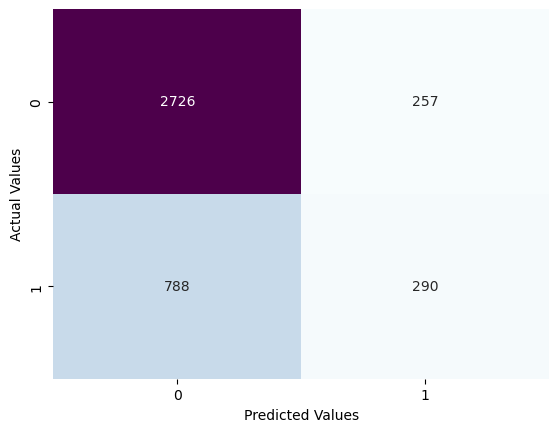

Classification report: 
              precision    recall  f1-score   support

           0       0.78      0.91      0.84      2983
           1       0.53      0.27      0.36      1078

    accuracy                           0.74      4061
   macro avg       0.65      0.59      0.60      4061
weighted avg       0.71      0.74      0.71      4061

Accuracy of the model:  0.7426742181728638


In [26]:
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
 
cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report: ")
 
print(classification_report(Y_test,Y_pred))
 
acc=accuracy_score(Y_test, Y_pred)
print("Accuracy of the model: ",acc)

In [27]:
#Print the score on training and test set
print("Train set score:{:.4f}".format(classifier.score(X_train, Y_train)))
print("Test set score: {:.4f}".format(classifier.score(X_test, Y_test)))

Train set score:0.7424
Test set score: 0.7427


In [28]:
#predicting using the Decision_Tree_Classifier
from sklearn.tree import DecisionTreeClassifier
 
model_DecisionTree = DecisionTreeClassifier(criterion="gini",random_state=10)
 
#fit the model on the data and predict the values
model_DecisionTree.fit(X_train,Y_train)
 
Y_pred = model_DecisionTree.predict(X_test)
#print(Y_pred)
#print(list(zip(Y_test,Y_pred)))

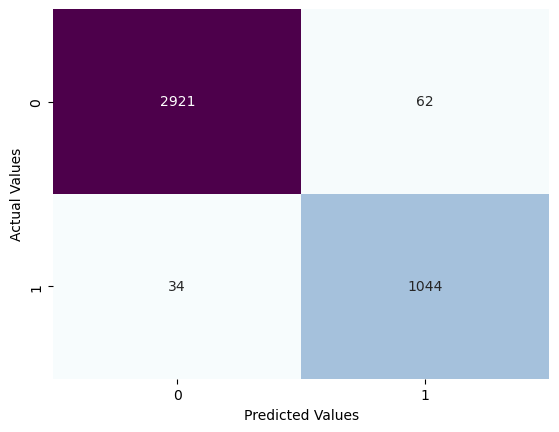

Classification report: 
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      2983
           1       0.94      0.97      0.96      1078

    accuracy                           0.98      4061
   macro avg       0.97      0.97      0.97      4061
weighted avg       0.98      0.98      0.98      4061

Accuracy of the model:  0.9763605023393253


In [29]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
 
cfm=confusion_matrix(Y_test,Y_pred)
sns.heatmap(cfm, annot=True, fmt='g', cbar=False, cmap='BuPu')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()

print("Classification report: ")
 
print(classification_report(Y_test,Y_pred))
 
acc=accuracy_score(Y_test, Y_pred)
print("Accuracy of the model: ",acc)

In [30]:
model_DecisionTree.score(X_train,Y_train)

1.0

In [31]:
hr_data.columns

Index(['Satisfaction Level', 'Last Evaluation', 'Number of Projects',
       'Monthly Hours', 'Total Time at the Company', 'Quit the Company',
       'Promoted in Last 5 yrs', 'Departments ', 'salary'],
      dtype='object')

In [32]:
print(list(zip(hr_data.columns[0:-1],model_DecisionTree.feature_importances_)))

[('Satisfaction Level', np.float64(0.5020450788567606)), ('Last Evaluation', np.float64(0.13937967463182027)), ('Number of Projects', np.float64(0.09961169414400382)), ('Monthly Hours', np.float64(0.08441491009422104)), ('Total Time at the Company', np.float64(0.15964134089679358)), ('Quit the Company', np.float64(3.4536591606896084e-05)), ('Promoted in Last 5 yrs', np.float64(0.011268432166441463)), ('Departments ', np.float64(0.0036043326183522826))]


In [33]:
print(list(zip(hr_data.columns[0:-1],model_DecisionTree.feature_importances_)))

[('Satisfaction Level', np.float64(0.5020450788567606)), ('Last Evaluation', np.float64(0.13937967463182027)), ('Number of Projects', np.float64(0.09961169414400382)), ('Monthly Hours', np.float64(0.08441491009422104)), ('Total Time at the Company', np.float64(0.15964134089679358)), ('Quit the Company', np.float64(3.4536591606896084e-05)), ('Promoted in Last 5 yrs', np.float64(0.011268432166441463)), ('Departments ', np.float64(0.0036043326183522826))]


In [34]:
print("Train set score:{:.4f}".format(model_DecisionTree.score(X_train, Y_train)))
print("Test set score: {:.4f}".format(model_DecisionTree.score(X_test, Y_test)))

Train set score:1.0000
Test set score: 0.9764


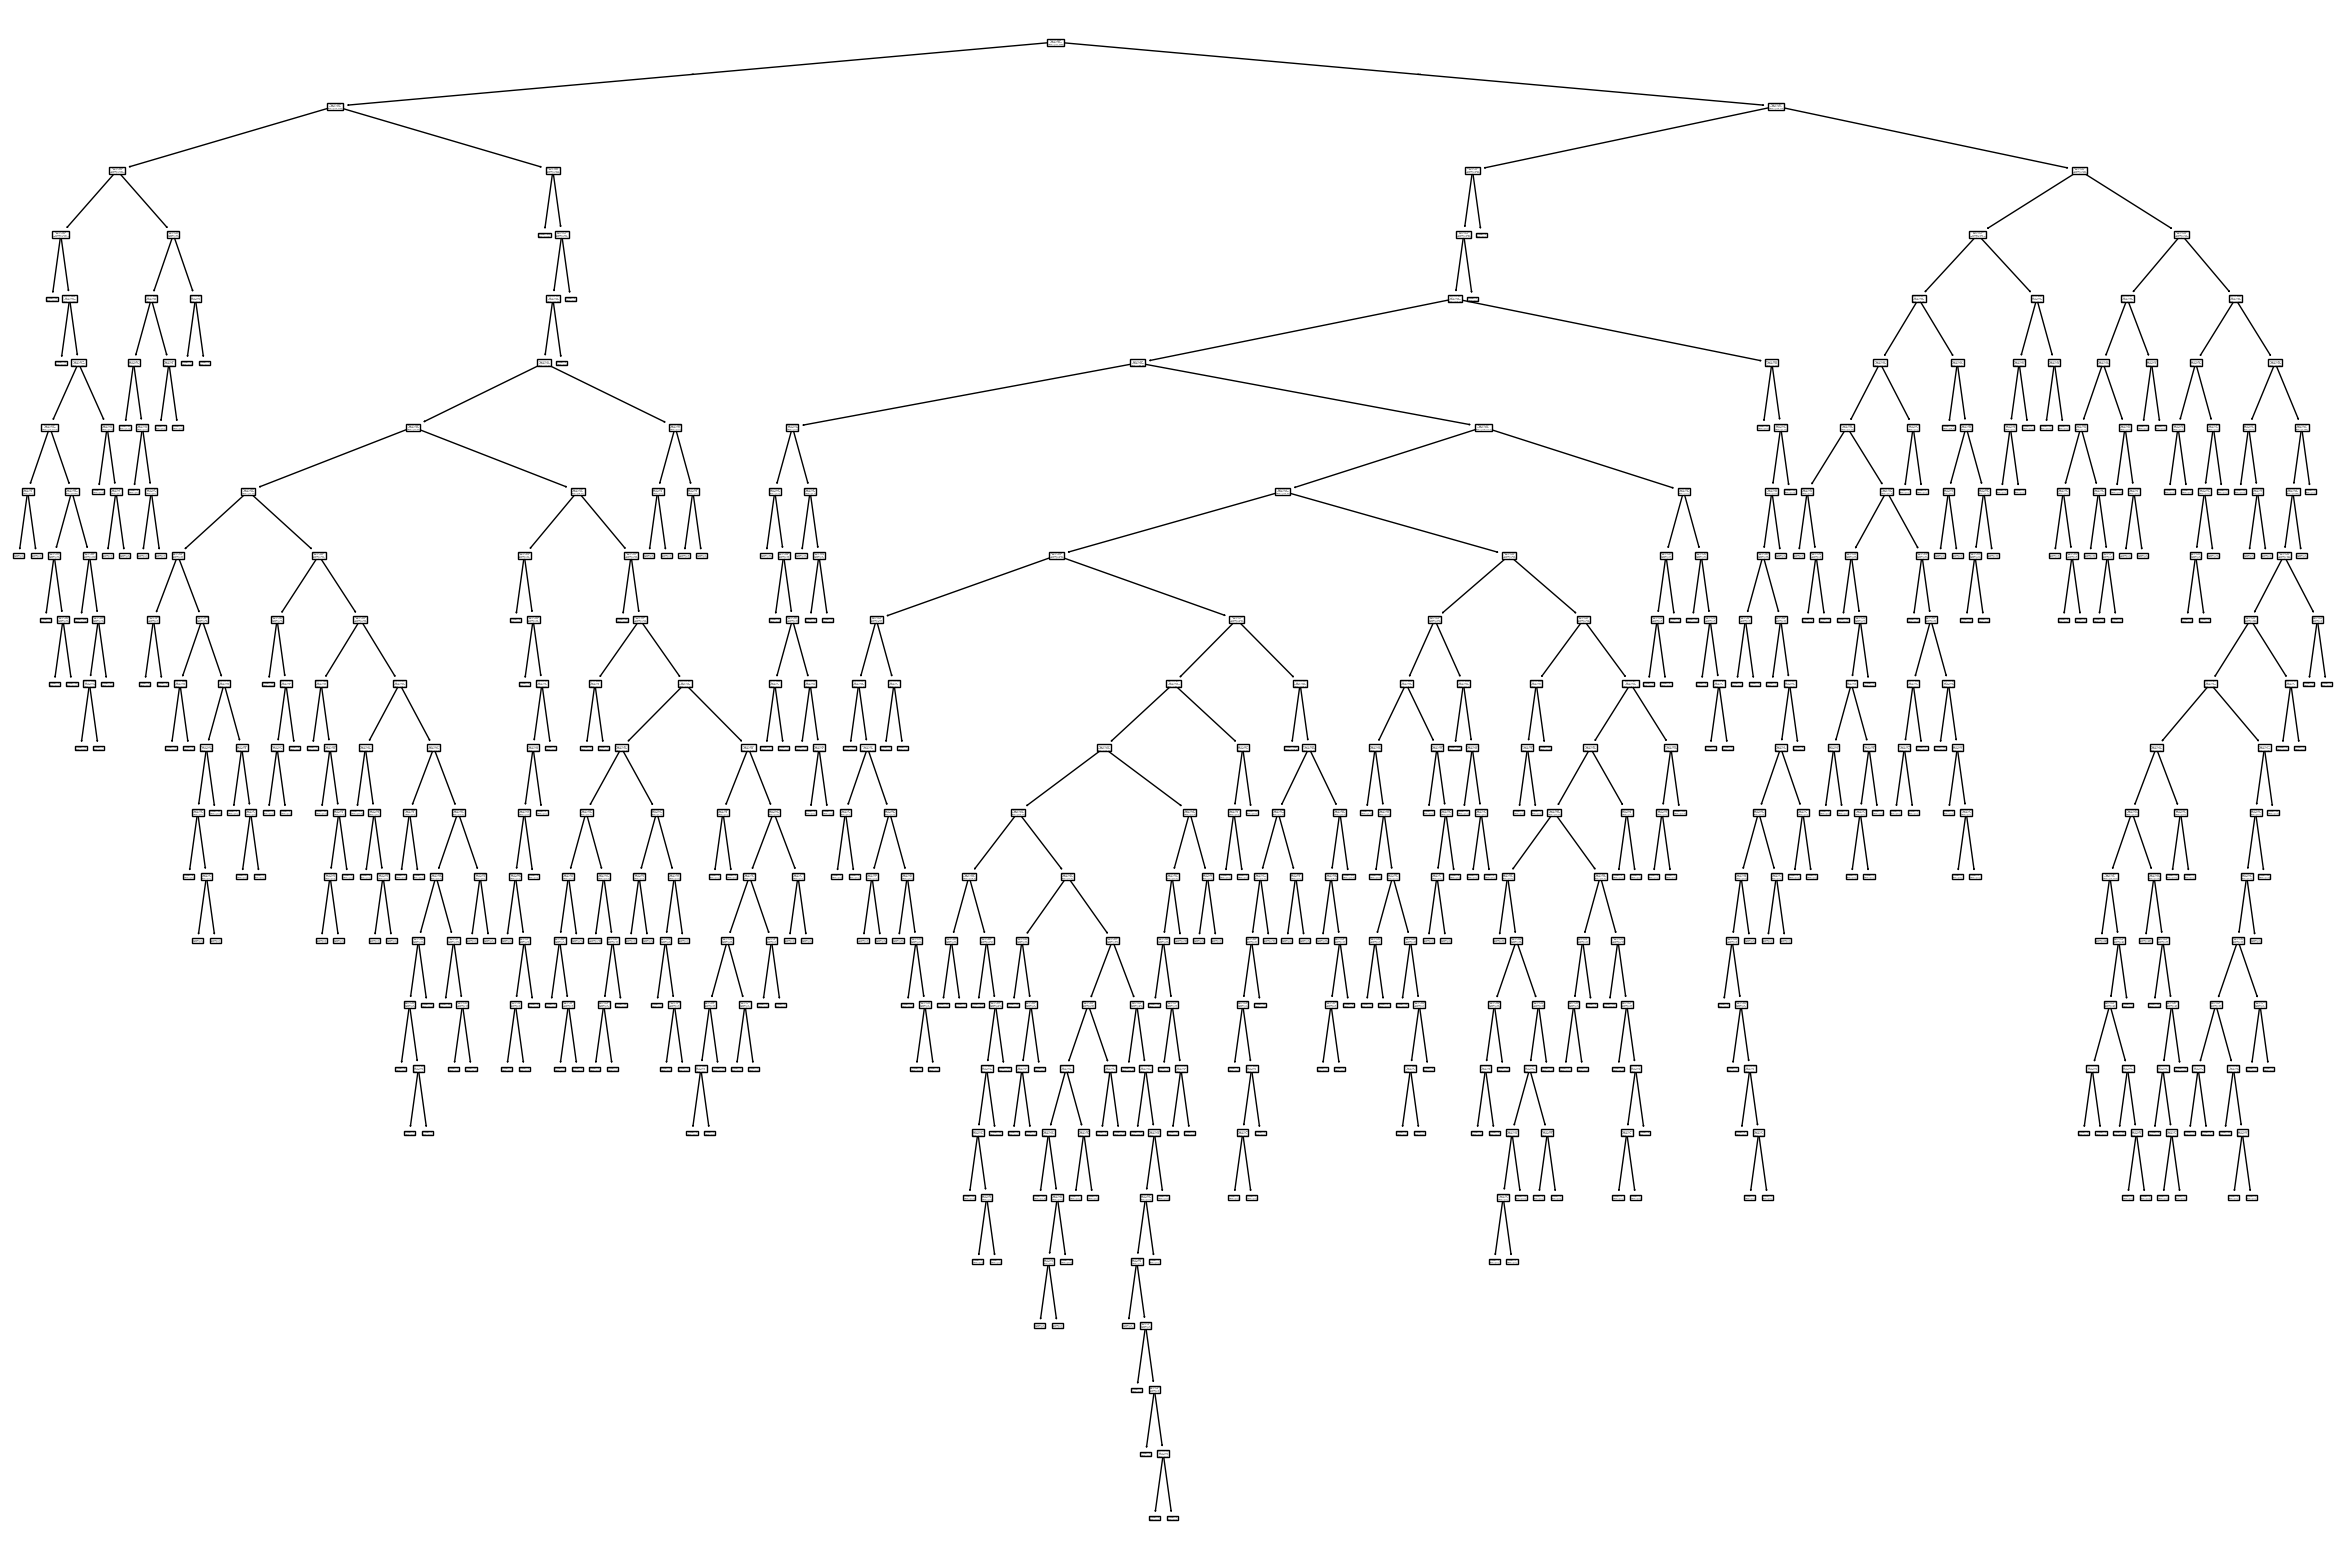

In [35]:
plt.figure(figsize=(30,20))

from sklearn import tree

tree.plot_tree(model_DecisionTree.fit(X_train , Y_train));

In [36]:
import joblib
 
joblib.dump({'dept': le_dept, 'salary': le_sal}, 'label_encoders.pkl')
joblib.dump(model_DecisionTree, 'model.pkl')

['model.pkl']

In [37]:
x_features = ['Satisfaction Level', 'Last Evaluation', 'Number of Projects',
       'Monthly Hours', 'Total Time at the Company','Promoted in Last 5 yrs', 'Departments ', 'salary']

In [38]:
x_features

['Satisfaction Level',
 'Last Evaluation',
 'Number of Projects',
 'Monthly Hours',
 'Total Time at the Company',
 'Promoted in Last 5 yrs',
 'Departments ',
 'salary']

In [39]:
!pip install gradio

In [40]:
import gradio as gr
 
model = joblib.load("model.pkl")
encoders = joblib.load("label_encoders.pkl")
 
def predict_hr_data(satisfaction_level, last_evaluation, number_projects,
                    montly_hours, time_spend_company,
                    promotion_last_5years, dept, salary):
    data = pd.DataFrame({
        'satisfaction_level': [satisfaction_level],
        'last_evaluation': [last_evaluation],
        'number_project': [number_projects],
        'average_montly_hours': [montly_hours],
        'time_spend_company': [time_spend_company],
        'promotion_last_5years': [promotion_last_5years],
        'dept': [dept],
        'salary': [salary]
    })
 
    for col in ['dept', 'salary']:
        le = encoders[col]
        data[col] = le.transform(data[col])
 
    prediction = model.predict(data)
    result = "Not Quitting the Company" if prediction[0] == 1 else "Quitting the Company"
    return result
 
inputs = [
    gr.Slider(0, 1, step=0.01, label="Satisfaction Level"),
    gr.Slider(0, 1, step=0.01, label="Last Evaluation"),
    gr.Slider(1, 10, step=1, label="Number of Projects"),
    gr.Slider(50, 350, step=10, label="Average Monthly Hours"),
    gr.Slider(1, 10, step=1, label="Time Spent in Company (Years)"),
    gr.Radio([0, 1], label="Promotion in Last 5 Years (0=No, 1=Yes)"),
    gr.Dropdown(encoders['dept'].classes_.tolist(), label="Department"),
    gr.Dropdown(encoders['salary'].classes_.tolist(), label="Salary Bracket")
]
 
output = gr.Textbox(label="Prediction Result")
 
app = gr.Interface(
    fn=predict_hr_data,
    inputs=inputs,
    outputs=output,
    title="HR Analytics Prediction App",
    description="Predict whether an employee is likely to leave based on HR data."
)
 
 
app.launch(inline=True)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
